In [2]:
import numpy as np
import mne
import os.path as op
import matplotlib.pyplot as plt 
import pandas as pd
import matplotlib.lines as mlines
import seaborn as sns
from fooof import FOOOF
from fooof import FOOOFGroup
from scipy.ndimage import gaussian_filter1d
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import pingouin as pg
from mpl_toolkits.axes_grid1 import make_axes_locatable

path = '/users/mgarson.stu/.anaconda/VML'
meg_path = op.join(path, 'MEG')
mri_path = op.join(path, 'MRI')

adult_subs = ['011', '012', '013','014', '018','019', '021','022','025', '026', '030', '031']
child_subs = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']

#Short Script to play with when playing with data 
load_dir = 'psd_data'

#Read in Data for main figure 
g_el_cerebellum_normalized_psds = np.load(op.join('psd_data', 'el_cerebellum_normalized_psds.npy'), allow_pickle=True)
g_ll_cerebellum_normalized_psds = np.load(op.join('psd_data', 'll_cerebellum_normalized_psds.npy'), allow_pickle=True)
#g_rl_cerebellum_normalized_psds = np.load(op.join('psd_data', 'rl_cerebellum_normalized_psds.npy'), allow_pickle=True)
g_el_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'el_cerebellum_normalized_psds_c.npy'), allow_pickle=True)
g_ll_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'll_cerebellum_normalized_psds_c.npy'), allow_pickle=True)
#g_rl_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'rl_cerebellum_normalized_psds_c.npy'), allow_pickle=True)

# Load Stds and significant frequencies
g_std_el_c = np.load(op.join('psd_data', 'std_el_c.npy'), allow_pickle=True)
g_std_ll_c = np.load(op.join('psd_data', 'std_ll_c.npy'), allow_pickle=True)
# g_std_rl_c = np.load(op.join('psd_data', 'std_rl_c.npy'), allow_pickle=True)
g_std_el_c_c = np.load(op.join('psd_data', 'std_el_c_c.npy'), allow_pickle=True)
g_std_ll_c_c = np.load(op.join('psd_data', 'std_ll_c_c.npy'), allow_pickle=True)
# g_std_rl_c_c = np.load(op.join('psd_data', 'std_rl_c_c.npy'), allow_pickle=True)

g_sig_freqs_cereb_age = np.load(op.join('psd_data', 'sig_freqs_cereb_age.npy'), allow_pickle=True)
g_sig_freqs_cereb_cond = np.load(op.join('psd_data', 'sig_freqs_cereb_cond.npy'), allow_pickle=True)
g_sig_freqs_cereb_int = np.load(op.join('psd_data', 'sig_freqs_cereb_int.npy'), allow_pickle=True)

g_el_motor_normalized_psds = np.load(op.join('psd_data', 'el_motor_normalized_psds.npy'), allow_pickle=True)
g_ll_motor_normalized_psds = np.load(op.join('psd_data', 'll_motor_normalized_psds.npy'), allow_pickle=True)
# g_rl_motor_normalized_psds = np.load(op.join('psd_data', 'rl_motor_normalized_psds.npy'), allow_pickle=True)
g_el_motor_normalized_psds_c = np.load(op.join('psd_data', 'el_motor_normalized_psds_c.npy'), allow_pickle=True)
g_ll_motor_normalized_psds_c = np.load(op.join('psd_data', 'll_omtor_normalized_psds_c.npy'), allow_pickle=True)  # Fixed "ll_omtor" typo
# g_rl_motor_normalized_psds_c = np.load(op.join('psd_data', 'rl_motor_normalized_psds_c.npy'), allow_pickle=True)

g_el_m_std = np.load(op.join('psd_data', 'el_m_std.npy'), allow_pickle=True)
g_ll_m_std = np.load(op.join('psd_data', 'll_m_std.npy'), allow_pickle=True)
# g_rl_m_std = np.load(op.join('psd_data', 'rl_m_std.npy'), allow_pickle=True)
g_el_m_c_std = np.load(op.join('psd_data', 'el_m_std_c.npy'), allow_pickle=True)
g_ll_m_c_std = np.load(op.join('psd_data', 'll_m_std_c.npy'), allow_pickle=True)
# g_rl_m_c_std = np.load(op.join('psd_data', 'rl_m_std_c.npy'), allow_pickle=True)

g_sig_freqs_m_age = np.load(op.join('psd_data', 'sig_freqs_m_age.npy'), allow_pickle=True)
g_sig_freqs_m_cond = np.load(op.join('psd_data', 'sig_freqs_m_cond.npy'), allow_pickle=True)
g_sig_freqs_m_int = np.load(op.join('psd_data', 'sig_freqs_m_int.npy'), allow_pickle=True)

# === Load Early Learning Averages ===
base_el_c_avg = np.load(op.join(load_dir, 'el_baseline_cerebellum_normalized_psd.npy'))
base_el_c_c_avg = np.load(op.join(load_dir, 'el_baseline_cerebellum_normalized_psd_c.npy'))
base_el_m_avg = np.load(op.join(load_dir, 'el_baseline_motor_normalized_psd.npy'))
base_el_m_c_avg = np.load(op.join(load_dir, 'el_baseline_motor_normalized_psd_c.npy'))

# === Load Late Learning Averages ===
base_ll_c_avg = np.load(op.join(load_dir, 'll_baseline_cerebellum_normalized_psd.npy'))
base_ll_c_c_avg = np.load(op.join(load_dir, 'll_baseline_cerebellum_normalized_psd_c.npy'))
base_ll_m_avg = np.load(op.join(load_dir, 'll_baseline_motor_normalized_psd.npy'))
base_ll_m_c_avg = np.load(op.join(load_dir, 'll_baseline_motor_normalized_psd_c.npy'))

# === Load Early Learning STDs ===
base_el_c_std = np.load(op.join(load_dir, 'el_baseline_cerebellum_normalized_psd_std.npy'))
base_el_c_c_std = np.load(op.join(load_dir, 'el_baseline_cerebellum_normalized_psd_c_std.npy'))
base_el_m_std = np.load(op.join(load_dir, 'el_baseline_motor_normalized_psd_std.npy'))
base_el_m_c_std = np.load(op.join(load_dir, 'el_baseline_motor_normalized_psd_c_std.npy'))

# === Load Late Learning STDs ===
base_ll_c_std = np.load(op.join(load_dir, 'll_baseline_cerebellum_normalized_psd_std.npy'))
base_ll_c_c_std = np.load(op.join(load_dir, 'll_baseline_cerebellum_normalized_psd_c_std.npy'))
base_ll_m_std = np.load(op.join(load_dir, 'll_baseline_motor_normalized_psd_std.npy'))
base_ll_m_c_std = np.load(op.join(load_dir, 'll_baseline_motor_normalized_psd_c_std.npy'))



C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23272\1743832250.py:8: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


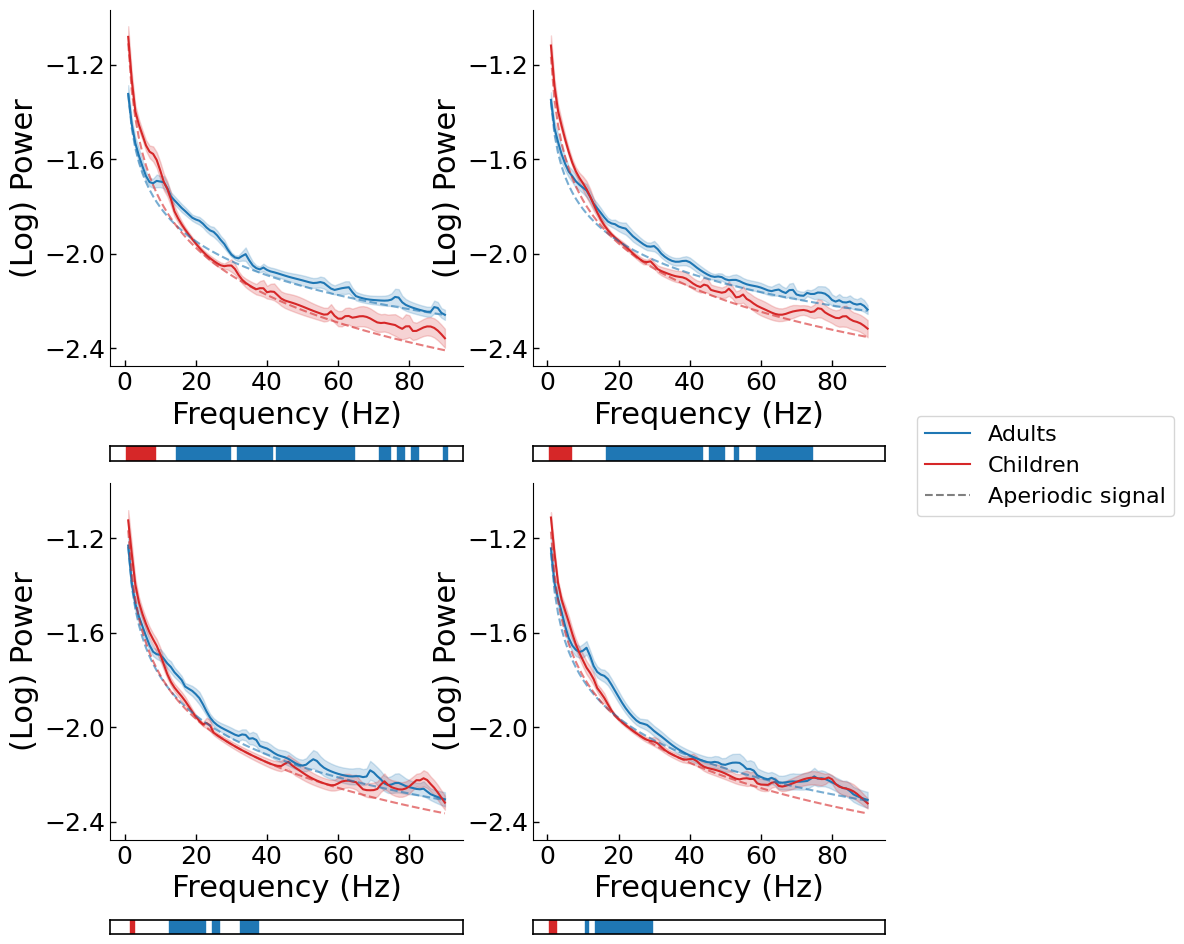

In [58]:
# Create the figure and axes grid *before* the loops
fig, axs = plt.subplots(2, 2, figsize=(10,12), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.05)
#fig.suptitle("Power Spectra \n in the Motor and Cerebellar Cortices", fontsize=24)

freqs = np.linspace(1,90,90)
freq_range = [1,90]

# Loop through each condition + region
for condition in ['g_el', 'g_ll']:
    for brain_region in ['motor', 'cerebellum']:
        # Dynamically load the right data
        adult_var_name = f"{condition}_{brain_region}_normalized_psds"
        child_var_name = f"{condition}_{brain_region}_normalized_psds_c"
        adult_data = globals()[adult_var_name]
        child_data = globals()[child_var_name]

        # Prep containers
        child_spectra, adult_spectra = [], [] 
        adult_backgrounds, child_backgrounds = [], []
        adult_slopes, child_slopes = [], []

        log_freqs = np.log10(freqs)
        theta_mask = (freqs >= 4) & (freqs <= 8)
        alpha_mask = (freqs >= 8) & (freqs <= 12)

        # === Adults
        for i in range(len(adult_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_data[i], freq_range)
            adult_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            adult_backgrounds.append(background)
            adult_slopes.append(slope)

        # === Children
        for i in range(len(child_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_data[i], freq_range)
            child_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            child_backgrounds.append(background)
            child_slopes.append(slope)


        #Save adult/children FOOFED spectra
        adult_spectra = np.array(adult_spectra)  # shape: [n_subjects, n_freqs]
        child_spectra = np.array(child_spectra)

        filename_adult = f'foofed_{condition}_{brain_region}_adult.npy'
        filename_child = f'foofed_{condition}_{brain_region}_child.npy'

        np.save(filename_adult, adult_spectra)
        np.save(filename_child, child_spectra)
        np.save(f'background_{condition}_{brain_region}_adult.npy', np.array(adult_backgrounds))
        np.save(f'background_{condition}_{brain_region}_child.npy', np.array(child_backgrounds))

        np.save(f'psd_data/slopes_task_{condition}_{brain_region}_child.npy', np.array(child_slopes))
        np.save(f'psd_data/slopes_task_{condition}_{brain_region}_adult.npy', np.array(adult_slopes))

        # === Averages
        avg_adult_spectrum = np.mean(adult_spectra, axis=0)
        avg_child_spectrum = np.mean(child_spectra, axis=0)
        avg_adult_background = np.mean(adult_backgrounds, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)

        # === Subplot mapping
        subplot_map = {
            ('g_el', 'motor'): (0, 0),
            ('g_ll', 'motor'): (0, 1),
            ('g_el', 'cerebellum'): (1, 0),
            ('g_ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]
        
        # === Create a connected significance axis below the main plot
        divider = make_axes_locatable(ax)
        sig_ax = divider.append_axes("bottom", size="4%", pad=0.8, sharex=ax)

        # Plot significant frequency squares
        p_array = np.load(f'FOOFed PSD data/pvals_{condition}_{brain_region}.npy')
        sig_mask = p_array < 0.05
        sig_freqs = freqs[sig_mask]
        for sf in sig_freqs:
            idx = np.argmin(np.abs(freqs - sf))
            color = 'tab:red' if avg_child_spectrum[idx] > avg_adult_spectrum[idx] else 'tab:blue'
            sig_ax.axvspan(sf - 0.5, sf + 0.5, color=color, alpha=1.0)

        # Format the significance axis (no ticks or labels)
        sig_ax.set_xlim(ax.get_xlim())
        sig_ax.set_ylim(-0.1, 0.1)
        sig_ax.set_xticks([])
        sig_ax.set_xticklabels([])
        sig_ax.set_yticks([])
        sig_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

        # Borders to match main plot
        for side in ['left', 'right', 'bottom', 'top']:
            sig_ax.spines[side].set_visible(True)
            sig_ax.spines[side].set_color('black')
            sig_ax.spines[side].set_linewidth(1.2)


        # === Plot
        ax.plot(freqs, avg_adult_spectrum, color='tab:blue', label='Adults')
        ax.plot(freqs, avg_child_spectrum, color='tab:red', label='Children')
        ax.plot(freqs, avg_adult_background, color='tab:blue', linestyle='--', alpha=0.6)
        ax.plot(freqs, avg_child_background, color='tab:red', linestyle='--', alpha=0.6)
        # ax.fill_between(freqs[theta_mask], avg_child_background[theta_mask], avg_child_spectrum[theta_mask],
        #                 color='tab:red', alpha=0.3)
        # ax.fill_between(freqs[alpha_mask], avg_adult_background[alpha_mask], avg_adult_spectrum[alpha_mask],
        #                 color='tab:blue', alpha=0.3)
        # ax.axvspan(4, 8, color='red', alpha=0.08)
        # ax.axvspan(8, 12, color='blue', alpha=0.08)
        
        # #Set Subplot Titles
        # ax.text(0.23, 0.92,
        # f"{brain_region.capitalize()} {'\n Early' if condition == 'g_el' else '\n Late'} Learning",
        # transform=ax.transAxes,
        # fontsize=16,
        # weight='bold',
        # verticalalignment='top',
        # bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        # === Compute SEM from FOOOFed Spectra
        adult_spectra = np.array(adult_spectra)  # shape: [n_subjects, n_freqs]
        child_spectra = np.array(child_spectra)

        sem_adult = np.std(adult_spectra, axis=0, ddof=1) / np.sqrt(adult_spectra.shape[0])
        sem_child = np.std(child_spectra, axis=0, ddof=1) / np.sqrt(child_spectra.shape[0])

        np.save(f'sem_{condition}_{brain_region}_adult.npy', sem_adult)
        np.save(f'sem_{condition}_{brain_region}_child.npy', sem_child)

        # === Error Shading (SEM)
        ax.fill_between(freqs, avg_adult_spectrum - sem_adult, avg_adult_spectrum + sem_adult,
                        color='tab:blue', alpha=0.2)
        ax.fill_between(freqs, avg_child_spectrum - sem_child, avg_child_spectrum + sem_child,
                        color='tab:red', alpha=0.2)
        
        # # Load p-values
        # p_array = np.load(f'FOOFed PSD data/pvals_{condition}_{brain_region}.npy')
        # sig_mask = p_array < 0.05
        # sig_freqs = freqs[sig_mask]

        # # === Plot significance markers below the axis
        # sig_y = -2.55  # adjust slightly below your min y-tick (-2.4)
        # ax.scatter(sig_freqs, [sig_y]*len(sig_freqs), color='black', marker='s', s=8, alpha=0.7, label='p < 0.05')
        # ax.set_ylim([-2.6, -1])  # extend lower limit to fit sig markers
        
        
        ax.set_xlabel('Frequency (Hz)', fontsize=22)
        ax.set_xticks([0, 20, 40, 60, 80])
        ax.set_xticklabels([0, 20, 40, 60, 80])
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

        ax.set_ylabel('(Log) Power', fontsize=22)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=18)  # or 14 if you want bigger
        #ax.tick_params(top=True, right=True, direction='in', length=4, width=1)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.tick_params(labelbottom=True)
        ax.tick_params(labelleft=True)
        ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')


# Custom aperiodic signal handle
aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

# Collect handles and labels from all subplots
handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Add the custom aperiodic signal
handles.append(aperiodic_handle)
labels.append('Aperiodic signal')

# Remove duplicates (optional)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=16)

#plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('poster/big_labels_Task_Periodic.png', dpi=300, bbox_inches='tight')
plt.show()

In [51]:
oone = np.load('psd_data/el_baseline_cerebellum_normalized_psd.npy')
print(np.shape(oone))

(12, 90)


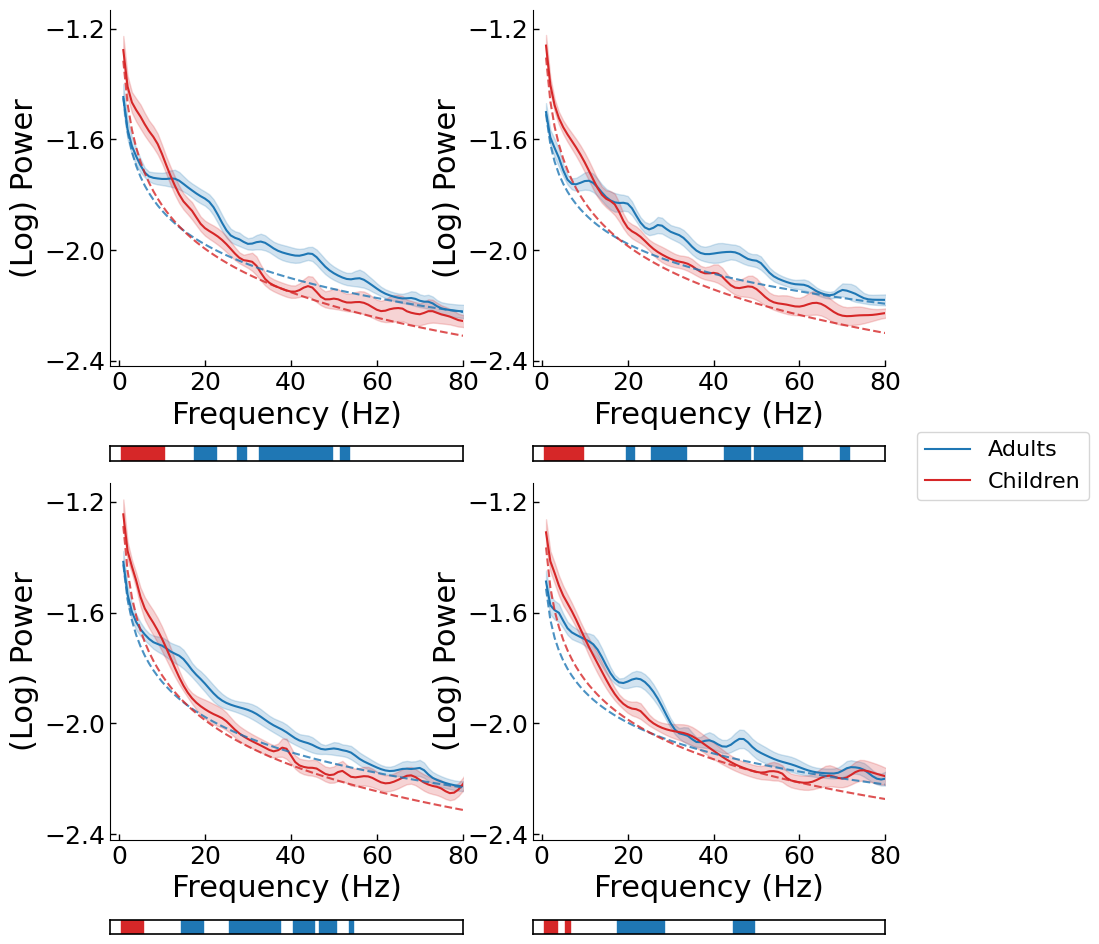

In [57]:
#Better Background Plotting Code 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1 import make_axes_locatable
from fooof import FOOOF

# === Set up figure and axes
fig, axs = plt.subplots(2, 2, figsize=(10, 12), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.05)

freqs = np.linspace(1, 90, 90)
freq_range = [1, 90]
log_freqs = np.log10(freqs)

# === Define conditions and regions
conditions = ['g_el', 'g_ll']
brain_regions = ['motor', 'cerebellum']

# === Subplot mapping
subplot_map = {
    ('g_el', 'motor'): (0, 0),
    ('g_ll', 'motor'): (0, 1),
    ('g_el', 'cerebellum'): (1, 0),
    ('g_ll', 'cerebellum'): (1, 1),
}

# === Loop over each condition × brain region
for condition in conditions:
    for brain_region in brain_regions:

        # Load data
        if condition == 'g_el': 
            path_child = f'psd_data/el_baseline_{brain_region}_normalized_psd_c.npy'
            path_adult = f'psd_data/el_baseline_{brain_region}_normalized_psd.npy'
        else:
            path_child = f'psd_data/ll_baseline_{brain_region}_normalized_psd_c.npy'
            path_adult = f'psd_data/ll_baseline_{brain_region}_normalized_psd.npy'

        child_background_data = np.load(path_child)  # shape (90, n_childs)
        adult_background_data = np.load(path_adult)  # shape (90, n_adults)

        # Prep containers
        child_spectra = []
        adult_spectra = []
        child_backgrounds = []
        adult_backgrounds = []
        child_slopes = []
        adult_slopes = []

        # === Adults
        for i in range(len(adult_subs)):
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_background_data[i], freq_range)
            adult_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            adult_backgrounds.append(background)
            adult_slopes.append(slope)

        # === Children
        for i in range(len(child_subs)):
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_background_data[i], freq_range)
            child_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            child_backgrounds.append(background)
            child_slopes.append(slope)

        # === Convert lists to arrays
        child_spectra = np.array(child_spectra)  # shape (n_childs, 90)
        adult_spectra = np.array(adult_spectra)

        np.save(f'psd_data/foofed_background_{condition}_{brain_region}_child.npy', child_spectra)
        np.save(f'psd_data/foofed_background_{condition}_{brain_region}_adult.npy', adult_spectra)

        np.save(f'psd_data/slopes_rest_{condition}_{brain_region}_child.npy', np.array(child_slopes))
        np.save(f'psd_data/slopes_rest_{condition}_{brain_region}_adult.npy', np.array(adult_slopes))

        child_backgrounds = np.array(child_backgrounds)
        adult_backgrounds = np.array(adult_backgrounds)

        # === Averages
        avg_child_spectrum = np.mean(child_spectra, axis=0)
        avg_adult_spectrum = np.mean(adult_spectra, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)
        avg_adult_background = np.mean(adult_backgrounds, axis=0)

        sem_child = np.std(child_spectra, axis=0, ddof=1) / np.sqrt(child_spectra.shape[0])
        sem_adult = np.std(adult_spectra, axis=0, ddof=1) / np.sqrt(adult_spectra.shape[0])

        # === Plotting
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]

        # Create significance axis below main axis
        divider = make_axes_locatable(ax)
        sig_ax = divider.append_axes("bottom", size="4%", pad=0.8, sharex=ax)
        sig_ax.set_xlim(ax.get_xlim())
        sig_ax.set_ylim(-0.1, 0.1)
        sig_ax.set_xticks([])
        sig_ax.set_xticklabels([])
        sig_ax.set_yticks([])
        sig_ax.set_yticklabels([])
        sig_ax.tick_params(axis='both', which='both', bottom=False, top=False, labelbottom=False, left=False, right=False, labelleft=False)

        for side in ['left', 'right', 'bottom', 'top']:
            sig_ax.spines[side].set_visible(True)
            sig_ax.spines[side].set_color('black')
            sig_ax.spines[side].set_linewidth(1.2)

        # === Try to load real p-values
        try:
            p_array = np.load(f'psd_data/pvals_background_{condition}_{brain_region}.npy')
            sig_mask = p_array < 0.05
            sig_freqs = freqs[sig_mask]
            for sf in sig_freqs:
                idx = np.argmin(np.abs(freqs - sf))
                color = 'tab:red' if avg_child_spectrum[idx] > avg_adult_spectrum[idx] else 'tab:blue'
                sig_ax.axvspan(sf - 0.5, sf + 0.5, color=color, alpha=1.0)
        except FileNotFoundError:
            pass

        # === Plot average fooofed spectra
        ax.plot(freqs, avg_adult_spectrum, color='tab:blue', label='Adults')
        ax.plot(freqs, avg_child_spectrum, color='tab:red', label='Children')

        # === Plot average aperiodic fits (dashed lines)
        ax.plot(freqs, avg_adult_background, color='tab:blue', linestyle='--', alpha=0.8)
        ax.plot(freqs, avg_child_background, color='tab:red', linestyle='--', alpha=0.8)

        # === Plot SEM shading
        ax.fill_between(freqs, avg_adult_spectrum - sem_adult, avg_adult_spectrum + sem_adult,
                        color='tab:blue', alpha=0.2)
        ax.fill_between(freqs, avg_child_spectrum - sem_child, avg_child_spectrum + sem_child,
                        color='tab:red', alpha=0.2)

        # === Style
        ax.set_xlim(left=-2)
        ax.set_xlabel('Frequency (Hz)', fontsize=22)
        ax.set_ylabel('(Log) Power', fontsize=22)
        ax.set_xticks([0, 20, 40, 60, 80])
        ax.set_xticklabels([0, 20, 40, 60, 80])
        ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        ax.tick_params(axis='both', labelsize=18)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')
        ax.tick_params(labelleft=True)
        ax.tick_params(labelbottom=True)



# === Create a single figure legend
aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Remove duplicates
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=16)

# Save and Show
plt.savefig('poster/big_labels_Baseline_Backgrounds_FOOOFed.png', dpi=300, bbox_inches='tight')
plt.show()


In [53]:
#Compare Aperiodic components: 
import numpy as np

conditions = ['g_el', 'g_ll']
brain_regions = ['motor', 'cerebellum']

for condition in conditions:
    for brain_region in brain_regions:
        # Load task and rest slopes
        task_child_slopes = np.load(f'psd_data/slopes_task_{condition}_{brain_region}_child.npy')
        task_adult_slopes = np.load(f'psd_data/slopes_task_{condition}_{brain_region}_adult.npy')
        
        rest_child_slopes = np.load(f'psd_data/slopes_rest_{condition}_{brain_region}_child.npy')
        rest_adult_slopes = np.load(f'psd_data/slopes_rest_{condition}_{brain_region}_adult.npy')

        # Compute averages
        avg_task_child = np.mean(task_child_slopes)
        avg_task_adult = np.mean(task_adult_slopes)
        avg_rest_child = np.mean(rest_child_slopes)
        avg_rest_adult = np.mean(rest_adult_slopes)

        # Compute differences
        diff_child = avg_task_child - avg_rest_child
        diff_adult = avg_task_adult - avg_rest_adult

        # Print
        print(f"{brain_region.capitalize()} - {condition.upper()}:")
        print(f"  Child Slope Difference (Task - Rest): {diff_child:.4f}")
        print(f"  Adult Slope Difference (Task - Rest): {diff_adult:.4f}")
        print()



Motor - G_EL:
  Child Slope Difference (Task - Rest): 0.1430
  Adult Slope Difference (Task - Rest): 0.0721

Cerebellum - G_EL:
  Child Slope Difference (Task - Rest): 0.0744
  Adult Slope Difference (Task - Rest): 0.1251

Motor - G_LL:
  Child Slope Difference (Task - Rest): 0.0841
  Adult Slope Difference (Task - Rest): 0.0924

Cerebellum - G_LL:
  Child Slope Difference (Task - Rest): 0.1329
  Adult Slope Difference (Task - Rest): 0.1656



In [41]:
import numpy as np
from scipy.stats import ttest_ind
import os

# Setup
conditions = ['g_el', 'g_ll']
regions = ['motor', 'cerebellum']

# Store p-values
background_pvals = {}

for cond in conditions:
    for region in regions:
        # Load saved fooofed background spectra
        child = np.load(f'psd_data/foofed_background_{cond}_{region}_child.npy')
        adult = np.load(f'psd_data/foofed_background_{cond}_{region}_adult.npy')

        # Perform t-test at each frequency
        t_stat, p = ttest_ind(adult, child, axis=0, equal_var=False)
        background_pvals[f'{cond}_{region}'] = p

        # Save p-values
        np.save(f'psd_data/pvals_background_{cond}_{region}.npy', p)

# Step 2: Optionally print significant frequencies
freqs = np.linspace(1, 90, 90)

for key, p in background_pvals.items():
    sig_freqs = freqs[p < 0.05]
    print(f"{key}: {sig_freqs}")
    
# print(f"All p-values for {key}:")
# print(p)
# print("\n")  # Add a line break between prints


g_el_motor: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 18. 19. 20. 21. 22. 28. 29. 33.
 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 52. 53.]
g_el_cerebellum: [ 1.  2.  3.  4.  5. 15. 16. 17. 18. 19. 26. 27. 28. 29. 30. 31. 32. 33.
 34. 35. 36. 37. 41. 42. 43. 44. 45. 47. 48. 49. 50. 54.]
g_ll_motor: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 20. 21. 26. 27. 28. 29. 30. 31. 32.
 33. 43. 44. 45. 46. 47. 48. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60.
 70. 71. 88. 89. 90.]
g_ll_cerebellum: [ 1.  2.  3.  6. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 45. 46. 47.
 48. 49.]


In [ ]:
#Backgrounds 